<a href="https://colab.research.google.com/github/JulietChinenyeDuru/African-Entrepreneurship-main/blob/main/nlp_classification_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Colab!

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


In [ ]:
# Load IMDb dataset (already tokenized as integers)
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=5000)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))


Training samples: 25000
Test samples: 25000


In [ ]:
maxlen = 200
X_train = pad_sequences(X_train, maxlen=maxlen)
X_test = pad_sequences(X_test, maxlen=maxlen)


In [ ]:
# Convert to bag-of-words using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
# For demonstration, we'll use a small sample of text reviews
# (IMDB dataset is already tokenized, so let's simulate with raw text)
sample_texts = ["I loved this movie, it was fantastic!",
                "Terrible film, waste of time.",
                "An average movie, not too bad but not great."]
sample_labels = [1, 0, 1]

X_vec = vectorizer.fit_transform(sample_texts)
y_vec = np.array(sample_labels)

# Train-test split
X_train_vec, X_test_vec, y_train_vec, y_test_vec = train_test_split(X_vec, y_vec, test_size=0.3, random_state=42)

# Models


In [ ]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(kernel="linear"),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

# Train and evaluate
for name, model in models.items():
    model.fit(X_train_vec, y_train_vec)
    y_pred = model.predict(X_test_vec)
    print(f"\n{name} Results:")
    print("Accuracy:", accuracy_score(y_test_vec, y_pred))
    print(classification_report(y_test_vec, y_pred))



Naive Bayes Results:
Accuracy: 1.0
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         1

    accuracy                           1.00         1
   macro avg       1.00      1.00      1.00         1
weighted avg       1.00      1.00      1.00         1


Logistic Regression Results:
Accuracy: 1.0
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         1

    accuracy                           1.00         1
   macro avg       1.00      1.00      1.00         1
weighted avg       1.00      1.00      1.00         1


SVM Results:
Accuracy: 1.0
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         1

    accuracy                           1.00         1
   macro avg       1.00      1.00      1.00         1
weighted avg       1.00      1.00      1.00         1


Random Forest Results:
Accuracy: 0.0
              precision    recall  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

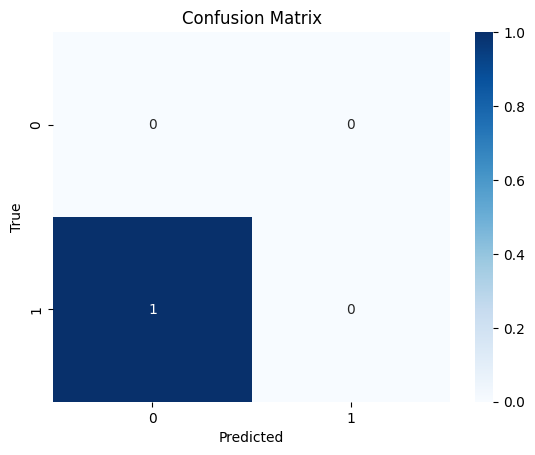

In [ ]:
cm = confusion_matrix(y_test_vec, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()
